# 03 — Cosine similarity and cell-type assignment

Compares each segmented cell's gene expression profile against the scRNA-seq prototypes
using cosine similarity. The prototype with the highest score determines the cell type.

**Inputs** (all produced by notebooks 01 and 02)
- `data/prototypes_normalized.csv`
- `data/cell_expression_aligned.csv`
- `data/shared_genes.txt`

**Outputs**
- `data/cosine_similarity_matrix.csv` — cells × cell_types similarity scores
- `data/cell_type_predictions.csv` — predicted type and best score per cell
- `outputs/figures/similarity_histogram.png`
- `outputs/figures/similarity_heatmap.png`
- `outputs/figures/cell_type_counts.png`

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

## Config

In [36]:
from pathlib import Path

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / ".git").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not locate the project root from the current working directory.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LEGACY_FIGURES_DIR = PROJECT_ROOT / "figures"
if LEGACY_FIGURES_DIR.exists():
    print(f"Using {FIGURES_DIR} for figures; legacy directory still exists at {LEGACY_FIGURES_DIR}")

PROTOTYPES_NORM_PATH = OUTPUT_DIR / "prototypes_normalized.csv"
CELL_EXPR_PATH       = OUTPUT_DIR / "cell_expression_aligned.csv"
SHARED_GENES_PATH    = OUTPUT_DIR / "shared_genes.txt"

SIM_MATRIX_PATH      = OUTPUT_DIR / "cosine_similarity_matrix.csv"
PREDICTIONS_PATH     = OUTPUT_DIR / "cell_type_predictions.csv"

MARKER_WEIGHTED_PREDICTIONS_PATH = OUTPUT_DIR / "cell_type_predictions_marker_weighted.csv"
MARKER_WEIGHTED_SIM_MATRIX_PATH = OUTPUT_DIR / "cosine_similarity_matrix_marker_weighted.csv"

HEATMAP_N_CELLS = 50

## 1 · Load inputs and align genes

We use `shared_genes.txt` as the single source of truth for gene ordering.
This guarantees that prototype columns and cell columns are aligned before any comparison.

In [37]:
with open(SHARED_GENES_PATH) as f:
    shared_genes = [line.strip() for line in f if line.strip()]

prototypes = pd.read_csv(PROTOTYPES_NORM_PATH, index_col=0)
cells = pd.read_csv(CELL_EXPR_PATH, index_col=0)

print("Prototypes raw:", prototypes.shape)
print("Cells raw:", cells.shape)
print("Shared genes:", len(shared_genes))

prototypes = prototypes.reindex(columns=shared_genes, fill_value=0)
cells = cells.reindex(columns=shared_genes, fill_value=0)

assert list(prototypes.columns) == shared_genes
assert list(cells.columns) == shared_genes

print("Aligned prototypes:", prototypes.shape)
print("Aligned cells:", cells.shape)

if cells.shape[1] != 5054:
    print("Warning: expected around 5054 genes. Check Notebook 02 output.")

Prototypes raw: (8, 5054)
Cells raw: (82, 5054)
Shared genes: 5054
Aligned prototypes: (8, 5054)
Aligned cells: (82, 5054)


## 2 · L2-normalise cell expression vectors

In [38]:
cells_norm = pd.DataFrame(
    normalize(cells.values, norm="l2"),
    index=cells.index,
    columns=cells.columns
)

# cells with zero counts across all genes can't be compared — drop them and warn
cell_sums = cells.sum(axis=1)
zero_cells = cell_sums == 0

if zero_cells.any():
    print(f"Warning: {zero_cells.sum()} cells have zero counts and will be excluded.")
    cells = cells.loc[~zero_cells].copy()

cells_norm = pd.DataFrame(
    normalize(cells.values, norm="l2"),
    index=cells.index,
    columns=cells.columns
)

## 3 · Compute cosine similarity

In [39]:
sim = cosine_similarity(cells_norm.values, prototypes.values)
sim_df = pd.DataFrame(
    sim,
    index=cells_norm.index,
    columns=prototypes.index
)
print("Similarity matrix:", sim_df.shape, "(cells × cell_types)")
print(sim_df.head(3))

Similarity matrix: (82, 8) (cells × cell_types)
cell_type  endothelial cell  endothelial cell of artery  \
cell_1             0.123209                    0.123726   
cell_2             0.073021                    0.069761   
cell_3             0.154247                    0.139572   

cell_type  endothelial cell of vascular tree  fibroblast  myofibroblast cell  \
cell_1                              0.121425    0.105729            0.115232   
cell_2                              0.072653    0.089567            0.081429   
cell_3                              0.142693    0.115063            0.127750   

cell_type  pericyte  vascular associated smooth muscle cell  \
cell_1     0.111348                                0.106745   
cell_2     0.086425                                0.077554   
cell_3     0.128355                                0.122310   

cell_type  vein endothelial cell  
cell_1                  0.123199  
cell_2                  0.076457  
cell_3                  0.142770  


### notes on cosine similarity results:
- vectors are very sparse and very noisy
- many genes irrelevant

But we're using cosine similarity for relative ranking and not magnitude!

## 4 · Assign cell types

In [40]:
results = pd.DataFrame({
    "predicted_cell_type": sim_df.idxmax(axis=1),
    "best_similarity":     sim_df.max(axis=1)
}, index=sim_df.index)

# regular predictions copy
regular_predictions = results.copy()

print(regular_predictions["predicted_cell_type"].value_counts())
print(f"\nMedian best similarity: {regular_predictions['best_similarity'].median():.3f}")

predicted_cell_type
endothelial cell                          30
vein endothelial cell                     16
fibroblast                                12
pericyte                                   8
endothelial cell of artery                 5
myofibroblast cell                         5
endothelial cell of vascular tree          4
vascular associated smooth muscle cell     2
Name: count, dtype: int64

Median best similarity: 0.104


## 5 · Save outputs

In [41]:
sim_df.to_csv(SIM_MATRIX_PATH)
results.to_csv(PREDICTIONS_PATH)
print(f"Saved similarity matrix   → {SIM_MATRIX_PATH}")
print(f"Saved cell type predictions → {PREDICTIONS_PATH}")

Saved similarity matrix   → /Users/mahsa/Projects/Computational-Genomics-Project/outputs/cosine_similarity_matrix.csv
Saved cell type predictions → /Users/mahsa/Projects/Computational-Genomics-Project/outputs/cell_type_predictions.csv


## 6 · Visualisations

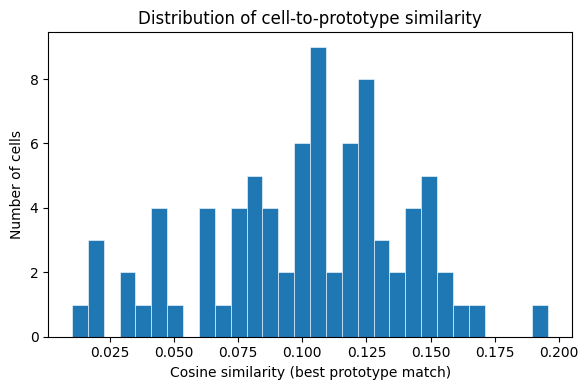

In [42]:
# distribution of best similarity scores
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(results["best_similarity"], bins=30, edgecolor="white", linewidth=0.4)
ax.set_xlabel("Cosine similarity (best prototype match)")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of cell-to-prototype similarity")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "similarity_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

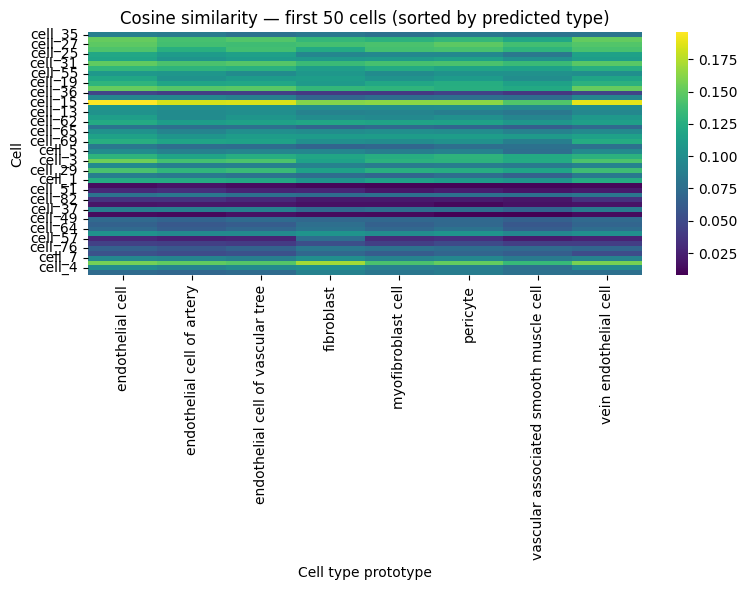

In [43]:
# heatmap — cells sorted by predicted type so structure is visible
sorted_idx = results.sort_values("predicted_cell_type").index
sim_subset = sim_df.loc[sorted_idx].iloc[:HEATMAP_N_CELLS]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sim_subset, cmap="viridis", ax=ax)
ax.set_title(f"Cosine similarity — first {HEATMAP_N_CELLS} cells (sorted by predicted type)")
ax.set_xlabel("Cell type prototype")
ax.set_ylabel("Cell")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "similarity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

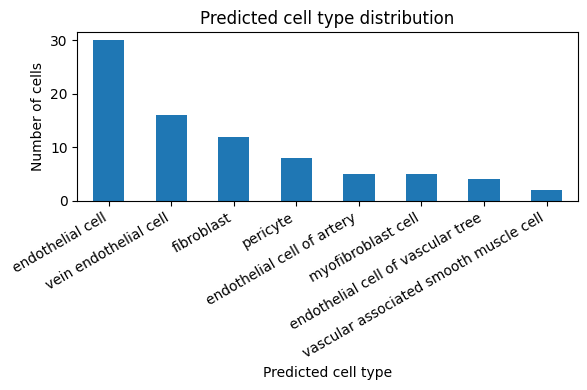

In [44]:
# bar chart of predicted cell type counts
counts = results["predicted_cell_type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax)
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("Number of cells")
ax.set_title("Predicted cell type distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cell_type_counts.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
# Marker-weighted cosine similarity

MARKER_GENES = {
    "fibroblast": ["DCN", "LUM", "PDGFRA", "COL1A1", "COL1A2"],
    "myofibroblast": ["ACTA2", "TAGLN", "MYL9", "COL3A1"],
    "endothelial": ["PECAM1", "VWF", "KDR", "RAMP2", "ENG"],
    "pericyte": ["RGS5", "PDGFRB", "MCAM", "CSPG4"],
    "vascular_smooth_muscle": ["ACTA2", "MYH11", "TAGLN", "MYLK"],
    "cycling": ["MKI67", "TOP2A", "UBE2C", "CENPF"],
    "immune": ["PTPRC", "CD3D", "CD3E", "MS4A1", "LYZ"],
    "epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
}

marker_gene_set = sorted({
    gene
    for genes in MARKER_GENES.values()
    for gene in genes
    if gene in cells.columns
})

print("Marker genes available:", len(marker_gene_set))
print(marker_gene_set)

if len(marker_gene_set) < 5:
    raise ValueError(
        "Too few marker genes found. Marker-weighted cosine is not meaningful."
    )

# Start with weight 1 for all genes.
gene_weights = pd.Series(1.0, index=cells.columns)

# Increase weight for marker genes.
MARKER_WEIGHT = 5.0
gene_weights.loc[marker_gene_set] = MARKER_WEIGHT

print("Total genes:", len(gene_weights))
print("Weighted marker genes:", (gene_weights > 1).sum())

Marker genes available: 21
['CD3D', 'CD3E', 'CENPF', 'CSPG4', 'DCN', 'ENG', 'EPCAM', 'KDR', 'LUM', 'MCAM', 'MKI67', 'MS4A1', 'MYH11', 'MYL9', 'MYLK', 'PDGFRA', 'PDGFRB', 'PECAM1', 'RGS5', 'TOP2A', 'UBE2C']
Total genes: 5054
Weighted marker genes: 21


In [46]:
# Apply gene weights

weighted_cells = cells.mul(gene_weights, axis=1)
weighted_prototypes = prototypes.mul(gene_weights, axis=1)

weighted_cells_norm = pd.DataFrame(
    normalize(weighted_cells.values, norm="l2", axis=1),
    index=weighted_cells.index,
    columns=weighted_cells.columns,
)

weighted_prototypes_norm = pd.DataFrame(
    normalize(weighted_prototypes.values, norm="l2", axis=1),
    index=weighted_prototypes.index,
    columns=weighted_prototypes.columns,
)

weighted_sim = pd.DataFrame(
    cosine_similarity(weighted_cells_norm.values, weighted_prototypes_norm.values),
    index=weighted_cells_norm.index,
    columns=weighted_prototypes_norm.index,
)

weighted_predictions = pd.DataFrame(index=weighted_sim.index)
weighted_predictions["predicted_cell_type"] = weighted_sim.idxmax(axis=1)
weighted_predictions["best_similarity"] = weighted_sim.max(axis=1)

sorted_scores = np.sort(weighted_sim.values, axis=1)
weighted_predictions["margin"] = sorted_scores[:, -1] - sorted_scores[:, -2]

display(weighted_predictions.head())
print(weighted_predictions["predicted_cell_type"].value_counts())

,predicted_cell_type,best_similarity,margin
cell_1,vascular associated smooth muscle cell,0.173655,0.028014
cell_2,vein endothelial cell,0.060768,0.002561
cell_3,endothelial cell,0.158054,0.003103
cell_4,vein endothelial cell,0.215125,0.014098
cell_5,endothelial cell of vascular tree,0.072518,0.000925


predicted_cell_type
vein endothelial cell                     26
endothelial cell                          19
endothelial cell of artery                19
vascular associated smooth muscle cell     7
endothelial cell of vascular tree          7
myofibroblast cell                         2
fibroblast                                 1
pericyte                                   1
Name: count, dtype: int64


In [47]:
# Save marker-weighted outputs

WEIGHTED_SIM_PATH = OUTPUT_DIR / "cosine_similarity_matrix_marker_weighted.csv"
WEIGHTED_PRED_PATH = OUTPUT_DIR / "cell_type_predictions_marker_weighted.csv"

weighted_sim.to_csv(WEIGHTED_SIM_PATH)
weighted_predictions.to_csv(WEIGHTED_PRED_PATH)

print(f"Saved weighted similarity matrix → {WEIGHTED_SIM_PATH}")
print(f"Saved weighted predictions → {WEIGHTED_PRED_PATH}")

Saved weighted similarity matrix → /Users/mahsa/Projects/Computational-Genomics-Project/outputs/cosine_similarity_matrix_marker_weighted.csv
Saved weighted predictions → /Users/mahsa/Projects/Computational-Genomics-Project/outputs/cell_type_predictions_marker_weighted.csv


In [48]:
# Compare regular vs marker-weighted cosine

comparison = pd.DataFrame({
    "regular_type": regular_predictions["predicted_cell_type"],
    "regular_score": regular_predictions["best_similarity"],
    "weighted_type": weighted_predictions["predicted_cell_type"],
    "weighted_score": weighted_predictions["best_similarity"],
})

comparison["type_changed"] = comparison["regular_type"] != comparison["weighted_type"]
comparison["score_delta"] = comparison["weighted_score"] - comparison["regular_score"]

print("Cells with changed predicted type:", comparison["type_changed"].sum(), "/", len(comparison))
print("Mean score delta:", comparison["score_delta"].mean())
print("Median score delta:", comparison["score_delta"].median())
print("Max score delta:", comparison["score_delta"].max())

display(comparison.head())

comparison.to_csv(OUTPUT_DIR / "regular_vs_marker_weighted_predictions.csv")

Cells with changed predicted type: 44 / 82
Mean score delta: 0.005084067690401917
Median score delta: -0.01760606440304399
Max score delta: 0.3681379292138998


,regular_type,regular_score,weighted_type,weighted_score,type_changed,score_delta
cell_1,endothelial cell of artery,0.123726,vascular associated smooth muscle cell,0.173655,True,0.049929
cell_2,fibroblast,0.089567,vein endothelial cell,0.060768,True,-0.028800
cell_3,endothelial cell,0.154247,endothelial cell,0.158054,False,0.003807
cell_4,fibroblast,0.100240,vein endothelial cell,0.215125,True,0.114885
cell_5,endothelial cell,0.098915,endothelial cell of vascular tree,0.072518,True,-0.026396


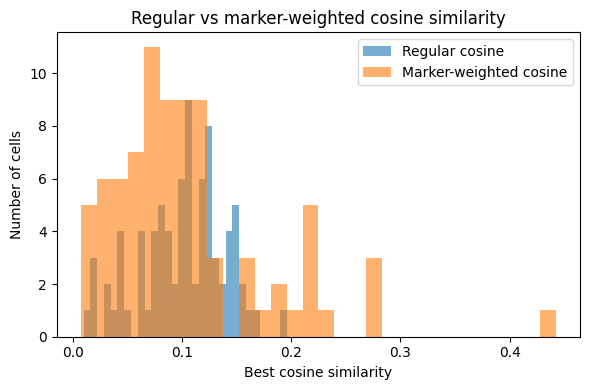

In [49]:
# Plot regular vs marker-weighted similarity

plt.figure(figsize=(6, 4))
plt.hist(comparison["regular_score"], bins=30, alpha=0.6, label="Regular cosine")
plt.hist(comparison["weighted_score"], bins=30, alpha=0.6, label="Marker-weighted cosine")
plt.xlabel("Best cosine similarity")
plt.ylabel("Number of cells")
plt.title("Regular vs marker-weighted cosine similarity")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "regular_vs_marker_weighted_similarity.png", dpi=300, bbox_inches="tight")
plt.show()

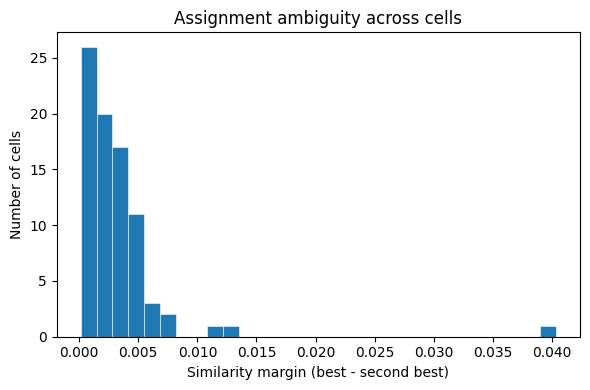

count    82.000000
mean      0.003193
std       0.004749
min       0.000124
25%       0.000931
50%       0.002300
75%       0.004093
max       0.040367
dtype: float64


In [50]:
# Margin distribution: best score - second-best score

sorted_scores = np.sort(sim_df.values, axis=1)
margins = sorted_scores[:, -1] - sorted_scores[:, -2]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(margins, bins=30, edgecolor="white", linewidth=0.4)
ax.set_xlabel("Similarity margin (best - second best)")
ax.set_ylabel("Number of cells")
ax.set_title("Assignment ambiguity across cells")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "similarity_margin_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

print(pd.Series(margins).describe())

#### Even though we can assign a cell type using cosine similarity, the margin between the top two candidates is often near zero, indicating high uncertainty.
#### This motivated our biological correction step, where we attempt to improve assignments only when there is meaningful evidence.

In [51]:
low_margin_pct = (margins < 0.01).mean() * 100
print(f"{low_margin_pct:.1f}% of cells have margin < 0.01")

96.3% of cells have margin < 0.01


#### How do we improve assignments when confidence is low?